<div style="font-family: system-ui, -apple-system, sans-serif; text-align: center; padding: 48px 24px 24px;">
    <div style="display: inline-block; background: #be0f05; color: white;
                padding: 12px 20px; border-radius: 12px; margin-bottom: 20px;">
        <span style="font-size: 34px; font-weight: 800; letter-spacing: -0.5px;">TIP4PATLIBS &ndash; Which lever moves the number?</span>
    </div>
    <div style="font-size: 16px; color: #475569; margin-bottom: 8px; line-height: 1.6;">
        A valuation is only useful if it says <strong>what to do about it</strong>. Here that answer is computed, not asserted.
    </div>
    <div style="font-size: 13px; color: #94a3b8; margin-bottom: 32px;">
        EPO Academy Training Material &nbsp;&middot;&nbsp; <a href="https://patentreports.depa.tech" target="_blank"
           style="color: #be0f05; text-decoration: none; font-weight: 600;">created by Arne Kr&uuml;ger</a>
        &nbsp;&middot;&nbsp; model: <strong>EPO IPScore 3.01</strong>
        &nbsp;&middot;&nbsp; scenario analysis after Riccardo Priore's NPV Target Planner
    </div>
    <div style="background: #f8fafc; border-radius: 12px; padding: 24px 28px; max-width: 680px;
                margin: 0 auto; border: 1px solid #e2e8f0; text-align: left;">
        <div style="font-size: 14px; color: #334155; line-height: 1.9;">
            <strong>What this notebook does</strong>
            <br/>Step&nbsp;1 &nbsp;&middot;&nbsp; The valuation as it stands
            <br/>Step&nbsp;2 &nbsp;&middot;&nbsp; Vary each of the eight levers across all five answers
            <br/>Step&nbsp;3 &nbsp;&middot;&nbsp; <strong>The tornado &mdash; how wide is each lever?</strong>
            <br/>Step&nbsp;4 &nbsp;&middot;&nbsp; Width is not the same as room: what is still on the table
            <br/>Step&nbsp;5 &nbsp;&middot;&nbsp; What exactly one better answer is worth
            <br/>Step&nbsp;6 &nbsp;&middot;&nbsp; Hand the section to the assembler
        </div>
    </div>
    <div style="background: #fdf2f2; border-radius: 10px; padding: 16px 24px; max-width: 680px;
                margin: 28px auto 0; border: 1px solid #fecaca;">
        <div style="font-size: 14px; color: #404955; font-weight: 600;">&#9654; &nbsp;Part 3 of 4 &mdash; runs anywhere, like parts 1 and 4.</div>
        <div style="font-size: 12px; color: #64748b; margin-top: 6px; line-height: 1.6;">
            No PATSTAT, no database, no internet. Run this <strong>before</strong>
            <code>4_assemble_tool.ipynb</code> and the report gains a sensitivity section;
            run it after, and re-run notebook&nbsp;4 to pick the section up.
        </div>
    </div>
</div>

---

## Step 1 — The valuation as it stands

The patent and the company figures come from `worked_example.json`. The **answers** come from
`kit.load_answers()`, which prefers notebook 2's measured set once that has been run on TIP and
otherwise falls back to the adviser's first pass — and says which. Notebook 4 reads exactly the
same two sources, so the three notebooks cannot describe different patents.

The sensitivity below is unaffected either way, and that is worth noticing: the eleven answers
notebook 2 can measure are **none of the eight** this notebook varies.

In [1]:
import pandas as pd
import plotly.graph_objects as go

import ipscore_kit as kit

spec = kit.load_spec()
example = kit.load_worked_example()

patent = example["patent"]
company = example["financials"]

# Notebook 2's measured set once it has run on TIP, otherwise the adviser's first pass.
answers, source = kit.load_answers()

prof = kit.profile(answers, spec)
value = kit.npv_from_answers(company, answers, spec)

print(patent["publication"], "-", patent["title"])
print(f"  {patent['applicant']} - {patent['field']}")
print(f"  answer set: {source}")
print()
print(f"Net Present Value   {value:,.0f} EUR")
print(f"Score               {prof.total_points} / {prof.max_points} points")
print(f"Provenance          {prof.provenance_counts['measured']} measured - "
      f"{prof.provenance_counts['informed']} informed - "
      f"{prof.provenance_counts['judgement']} judgement")

EP3074539B1 - Method for detecting and characterising a microorganism
  Q-Linea AB, Uppsala (SE) - in-vitro diagnostics / antimicrobial resistance
  answer set: measured against PATSTAT for EP3074539B1 by 2_evidence_from_patstat.ipynb

Net Present Value   -69,726 EUR
Score               61 / 200 points
Provenance          2 measured - 6 informed - 32 judgement


---

## Step 2 — Vary each lever across all five answers

A client rarely wants the number on its own. They want to know **which answer to work on** —
and that is a question the model can answer by itself, because only eight of the forty
questions reach the NPV at all.

So: take each of those eight in turn, walk its answer from 1 to 5 while everything else stays
exactly where it is, and record the NPV each time. Eight questions × five answers = forty
valuations, which is nothing for a computer and impossible by hand. That is the whole reason
the model was built as arithmetic rather than as a spreadsheet of opinions.

> **One honest caveat, stated once and meant throughout.** This is a *one-at-a-time* analysis.
> The levers do interact — moving `life_expectancy` changes what a step in `market_growth` is
> worth — so these widths do not add up to anything and must not be read as a decomposition of
> the NPV. They answer "which single answer would I most want to be wrong about", which is the
> question a client actually asks.

In [2]:
levers = kit.sensitivity(company, answers, spec)

table = pd.DataFrame([{
    "Question": r.question_id,
    "What it asks": r.factor,
    "Parameter": r.param,
    "Now": r.current_score,
    "Best answer": r.best_score,
    "Swing": r.swing,
    "Upside left": r.upside,
    "Downside risk": r.downside,
    "One step up": r.step_up,
    "One step down": r.step_down,
} for r in levers])

pd.set_option("display.float_format", lambda v: f"{v:,.0f}")
table

,Question,What it asks,Parameter,Now,Best answer,Swing,Upside left,Downside risk,One step up,One step down
0,D2,Future cost of development,development_cost_share,1,5,"63,805","63,805",0,"32,443",None
1,B5,Pre-commercial term of development,years_to_market,1,4,"61,406","61,406",0,"32,606",None
2,C3,Life expectancy,life_expectancy,1,1,"25,194",0,"-25,194","-3,525",None
3,D3,Cost of production,production_cost_index,1,5,"7,083","7,083",0,"1,771",None
4,C2,Market growth rate,market_growth,1,1,"6,027",0,"-6,027",-608,None
5,D4,Investment intensity,investment_index,1,5,"4,606","4,606",0,658,None
6,D1,Business output maintainability,output_maintainable,1,5,"3,915","3,915",0,979,None
7,C6,Potential extra turnover,extra_turnover_share,1,1,17,0,-17,-3,None


---

## Step 3 — The tornado: how wide is each lever?

The classic picture. Each bar runs from the NPV you would get with this question's **worst**
answer to the NPV you would get with its **best**, everything else held still. The vertical
line is where the valuation stands today; the part of the bar to the left of it is what you
stand to lose, the part to the right is what you could still gain.

Sorted widest first, so the top bar is the answer this valuation is most sensitive to.

And at the bottom, the finding that matters most: **thirty-two of the forty questions have a
bar of exactly zero width.** They shape the profile and the conversation — legal status, claim
breadth, enforcement, strategy — and they change the number by nothing at all. Any tool that
lets a client believe otherwise is misleading them.

In [3]:
ORDER = list(reversed(levers))          # plotly draws the first row at the bottom
labels = [f"{r.question_id} &#183; {r.factor}" for r in ORDER]

fig_tornado = go.Figure()
fig_tornado.add_trace(go.Bar(
    y=labels, x=[r.current_npv - min(r.npv_by_score) for r in ORDER],
    base=[min(r.npv_by_score) for r in ORDER],
    orientation="h", name="what a worse answer costs",
    marker={"color": kit.PALETTE["investments"]},
    hovertemplate="down to %{base:,.0f} EUR<extra></extra>",
))
fig_tornado.add_trace(go.Bar(
    y=labels, x=[max(r.npv_by_score) - r.current_npv for r in ORDER],
    base=[r.current_npv for r in ORDER],
    orientation="h", name="what a better answer is worth",
    marker={"color": kit.PALETTE["efficiency"]},
    hovertemplate="up to %{x:,.0f} EUR more<extra></extra>",
))
fig_tornado.add_trace(go.Bar(
    y=["the other 32 answers &#183; no effect whatsoever"], x=[0], base=[value],
    orientation="h", name="cannot move the NPV at all",
    marker={"color": kit.PALETTE["inactive"], "line": {"width": 3, "color": kit.PALETTE["ink_muted"]}},
    hovertemplate="exactly 0 EUR<extra></extra>",
))
fig_tornado.add_vline(x=value, line={"color": kit.PALETTE["ink"], "width": 2, "dash": "dot"},
                      annotation_text=f"  today: {value:,.0f} EUR",
                      annotation_position="top right",
                      annotation_font={"color": kit.PALETTE["ink"], "size": 12})

fig_tornado.update_layout(
    **kit.CHART_LAYOUT, barmode="overlay", height=470,
    title="How far each answer could move the valuation, one answer at a time",
)
fig_tornado.update_xaxes(title="Net Present Value (EUR)", tickformat=",.0f")
fig_tornado.update_yaxes(title=None, automargin=True)
fig_tornado.show()

---

## Step 4 — Width is not the same as room

The tornado ranks levers by how wide they are. That is not the same as how much is **still
available**, and confusing the two is the easiest way to give a client bad advice.

A lever can be enormously wide and offer nothing, because the answer is already the best one
on the scale — there is no move left to make. Look for exactly that in the output below: the
widest bar in the tornado is not necessarily the one worth working on.

In [4]:
room = pd.DataFrame([{
    "Question": r.question_id,
    "What it asks": r.factor,
    "Now": r.current_score,
    "Swing (width)": r.swing,
    "Upside left": r.upside,
    "Already at the best answer": r.current_score == r.best_score,
} for r in levers]).sort_values("Upside left", ascending=False)

maxed = [r.question_id for r in levers if r.current_score == r.best_score]
widest = levers[0]
roomiest = max(levers, key=lambda r: r.upside)

print(f"Widest lever        {widest.question_id} - {widest.factor}")
print(f"                    swing {widest.swing:,.0f} EUR, but only {widest.upside:,.0f} EUR left to gain")
print(f"Most room to gain   {roomiest.question_id} - {roomiest.factor}  (+{roomiest.upside:,.0f} EUR)")
print(f"Already maxed out   {', '.join(maxed) if maxed else 'none'}\n")
room

Widest lever        D2 - Future cost of development
                    swing 63,805 EUR, but only 63,805 EUR left to gain
Most room to gain   D2 - Future cost of development  (+63,805 EUR)
Already maxed out   C3, C2, C6



,Question,What it asks,Now,Swing (width),Upside left,Already at the best answer
0,D2,Future cost of development,1,"63,805","63,805",False
1,B5,Pre-commercial term of development,1,"61,406","61,406",False
3,D3,Cost of production,1,"7,083","7,083",False
5,D4,Investment intensity,1,"4,606","4,606",False
6,D1,Business output maintainability,1,"3,915","3,915",False
2,C3,Life expectancy,1,"25,194",0,True
4,C2,Market growth rate,1,"6,027",0,True
7,C6,Potential extra turnover,1,17,0,True


---

## Step 5 — What exactly one better answer is worth

The tornado assumes you could move an answer all the way to the best one. Usually you cannot.
The realistic question is what **one step** is worth — one answer better, one answer worse —
and that is the number to put in front of a client.

Read it as a to-do list ranked by money: the longest green bar is where the next unit of effort
buys the most, and the longest red bar is the assumption most worth double-checking before you
send the valuation out.

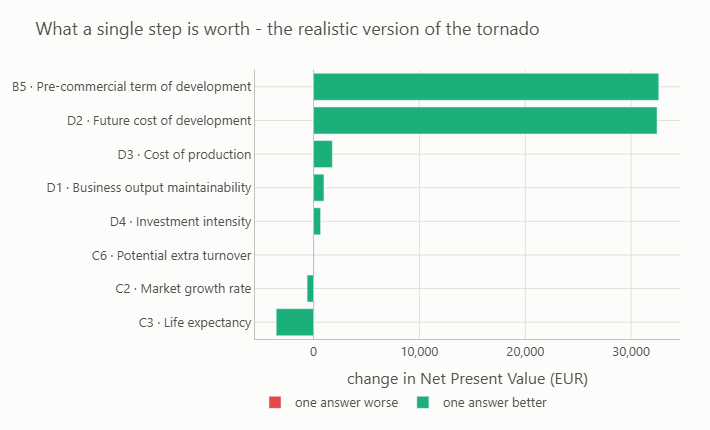

B5: one answer better on 'Pre-commercial term of development' is worth +32,606 EUR
D2: one answer better on 'Future cost of development' is worth +32,443 EUR
D3: one answer better on 'Cost of production' is worth +1,771 EUR


In [5]:
steps = sorted(levers, key=lambda r: (r.step_up or 0))
step_labels = [f"{r.question_id} &#183; {r.factor}" for r in steps]

fig_steps = go.Figure()
fig_steps.add_trace(go.Bar(
    y=step_labels, x=[r.step_down or 0 for r in steps], orientation="h",
    name="one answer worse", marker={"color": kit.PALETTE["investments"]},
    hovertemplate="%{x:,.0f} EUR<extra>one answer worse</extra>",
))
fig_steps.add_trace(go.Bar(
    y=step_labels, x=[r.step_up or 0 for r in steps], orientation="h",
    name="one answer better", marker={"color": kit.PALETTE["efficiency"]},
    hovertemplate="+%{x:,.0f} EUR<extra>one answer better</extra>",
))
fig_steps.add_vline(x=0, line={"color": kit.PALETTE["axis"], "width": 1})
fig_steps.update_layout(
    **kit.CHART_LAYOUT, barmode="relative", height=430,
    title="What a single step is worth - the realistic version of the tornado",
)
fig_steps.update_xaxes(title="change in Net Present Value (EUR)", tickformat=",.0f")
fig_steps.update_yaxes(title=None, automargin=True)
fig_steps.show()

for r in sorted(levers, key=lambda r: -(r.step_up or 0))[:3]:
    if r.step_up:
        print(f"{r.question_id}: one answer better on '{r.factor}' is worth {r.step_up:+,.0f} EUR")

---

## Step 6 — Hand the section to the assembler

Notebook 4 builds the report's spine by itself — verdict, profile, the eight money answers, the
cash flow, all forty answers. This notebook has **one extra section** to add, so it hands it
over through `kit.record_section`: the two figures as inline HTML, the numbers as workbook
rows, and an `order` that decides where the section lands (700 — after the cash flow, before
the full questionnaire).

Nothing here is an iframe. Jupyter serves `/files/` under a CSP sandbox that disables
JavaScript, so an iframed chart is a blank rectangle inside TIP.

**Then re-run `4_assemble_tool.ipynb`** — it picks this up automatically.

In [6]:
OUTPUT_DIR = "3_valuation_and_scenarios_output"

fragment = "".join(
    fig.to_html(full_html=False, include_plotlyjs=False, div_id=div, default_width="100%")
    for fig, div in [(fig_tornado, "fig_tornado"), (fig_steps, "fig_steps")]
)

path = kit.record_section(
    700, "sensitivity", "Which lever actually moves the number?",
    fragment_html=fragment,
    note=("One answer varied at a time, everything else held still. The other 32 questions "
          "have a swing of exactly zero."),
    sheets={"sensitivity": table.to_dict("records")},
    output_dir=OUTPUT_DIR,
)

print(f"Recorded section 700 -> {path.parent}")
for entry in kit.load_sections():
    print(f"  {entry['order']}  {entry['title']}  ({len(entry['sheets'])} sheet(s))")

Recorded section 700 -> 3_valuation_and_scenarios_output/_report_parts
  450  What the record actually says  (1 sheet(s))
  700  Which lever actually moves the number?  (1 sheet(s))


---

## Done — the answer to "what should we do about it?"

The valuation now comes with a ranked, computed answer instead of an assertion. Three things
worth carrying out of this notebook:

* **Only eight answers can move the number**, and this notebook makes that visible rather than
  merely stating it — thirty-two bars of zero width.
* **The widest lever is not always the one to work on.** Width tells you what the answer is
  worth in principle; upside tells you what is still available. Advise on the second.
* **These are one-at-a-time results.** The levers interact, so the widths do not add up. They
  rank; they do not decompose.

Re-run **`4_assemble_tool.ipynb`** and the report gains this section automatically, with its
numbers in the data workbook.